<a href="https://colab.research.google.com/github/SANGUNDE/ML-/blob/main/cats%20and%20dogs%20classification%20using%20CNN%20with%20data%20augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mayungosangunde","key":"f8ebc34de4c7e6dc78bec5414bfa34dd"}'}

In [2]:
!mkdir ~/.kaggle

In [3]:
!cp kaggle.json ~/.kaggle/

In [4]:
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle competitions download -c dogs-vs-cats

 99% 801M/812M [00:03<00:00, 172MB/s]
100% 812M/812M [00:04<00:00, 212MB/s]


In [6]:
!unzip -qq dogs-vs-cats.zip

In [7]:
!unzip -qq train.zip

In [8]:
import os, shutil, pathlib

In [9]:
original_dir = pathlib.Path('train')
new_working_dir = pathlib.Path('cats_vs_dogs_dataset')

In [10]:
import os
import shutil
from pathlib import Path
import random

source_dir = Path("train")
output_dir = Path("dogs and cats")


split_sizes = {
    "train": 1000,
    "val": 500,
    "test": 1000
}


for split in split_sizes:
    for label in ["cats", "dogs"]:
        (output_dir / split / label).mkdir(parents=True, exist_ok=True)


def get_label(filename):
    name = filename.lower()
    if "cat" in name:
        return "cats"
    elif "dog" in name:
        return "dogs"
    else:
        return None


all_images = [f for f in source_dir.iterdir() if f.is_file()]
random.shuffle(all_images)

images_by_label = {"cats": [], "dogs": []}
for img in all_images:
    label = get_label(img.name)
    if label:
        images_by_label[label].append(img)

def distribute_images(label):
    imgs = images_by_label[label]
    total_needed = sum(split_sizes.values())
    if len(imgs) < total_needed:
        print(f"⚠ Not enough {label} images. Found {len(imgs)}, need {total_needed}.")
        return

    start = 0
    for split, count in split_sizes.items():
        end = start + count
        for img in imgs[start:end]:
            dest = output_dir / split / label / img.name
            shutil.copy(img, dest)
        start = end

for label in ["cats", "dogs"]:
    distribute_images(label)

print("✅ Dataset split complete.")

✅ Dataset split complete.


In [11]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt


In [12]:
#creating the model

model = keras.Sequential()
inputs = keras.Input(shape=(180,180, 3))
x = keras.layers.Rescaling(1. / 255)(inputs)
x = keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu')(x)
pool_1 = keras.layers.MaxPooling2D(pool_size=2)(x)
x = keras.layers.Conv2D(filters=64, kernel_size=3, activation='relu')(pool_1)
pool_2 = keras.layers.MaxPooling2D(pool_size=2)(x)
x = keras.layers.Conv2D(filters=128, kernel_size=3, activation='relu')(pool_2)
pool_3 = keras.layers.MaxPooling2D(pool_size=2)(x)
x = keras.layers.Conv2D(filters=256, kernel_size=3, activation='relu')(pool_3)
pool_4 = keras.layers.MaxPooling2D(pool_size=2)(x)
x = keras.layers.Conv2D(filters=256, kernel_size=3, activation='relu')(pool_4)
flatten = keras.layers.Flatten()(x)

outputs = keras.layers.Dense(1 , activation='sigmoid')(flatten)

model = keras.Model(inputs=inputs, outputs = outputs)




In [13]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        12,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 991,041 (3.78 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:

#compiling

model.compile(optimizer='rmsprop',
              loss = 'binary_crossentropy',
              metrics=['accuracy'])

In [15]:
from keras.utils import image_dataset_from_directory

In [16]:
train_dataset = image_dataset_from_directory(
 output_dir / "train",
 image_size=(180, 180),
 batch_size=32)
validation_dataset = image_dataset_from_directory(
output_dir / "val",
 image_size=(180, 180),
 batch_size=32)
test_dataset = image_dataset_from_directory(
 output_dir / "test",
 image_size=(180, 180),
 batch_size=32)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


In [17]:
for data_batch, labels_batch in train_dataset:
  print(data_batch.shape)
  print(labels_batch.shape)
  break

(32, 180, 180, 3)
(32,)


In [18]:
callback = [keras.callbacks.ModelCheckpoint(
    filepath='convnet.keras',
    monitor='val_loss',
    save_best_only=True
)]



In [19]:
history = model.fit(train_dataset, epochs=35,
                    validation_data=validation_dataset,
                    callbacks=callback)

Epoch 1/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 220s 3s/step - accuracy: 0.5099 - loss: 0.7176 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 2/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 261s 3s/step - accuracy: 0.5149 - loss: 0.6940 - val_accuracy: 0.6410 - val_loss: 0.6845
Epoch 3/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 247s 3s/step - accuracy: 0.5538 - loss: 0.6928 - val_accuracy: 0.5690 - val_loss: 0.6754
Epoch 4/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 223s 4s/step - accuracy: 0.5997 - loss: 0.6698 - val_accuracy: 0.6390 - val_loss: 0.6333
Epoch 5/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 254s 3s/step - accuracy: 0.6220 - loss: 0.6393 - val_accuracy: 0.6220 - val_loss: 0.6339
Epoch 6/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 269s 4s/step - accuracy: 0.6465 - loss: 0.6180 - val_accuracy: 0.6840 - val_loss: 0.6152
Epoch 7/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 254s 3s/step - accuracy: 0.6893 - loss: 0.5828 - val_accuracy: 0.6280 - val_loss: 0.8465
Epoch 8/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 248s 3s/step - accuracy: 0.6882 - loss: 0.5820 - val_accuracy: 0.6920 - v

In [20]:
model.evaluate(test_dataset)

63/63 ━━━━━━━━━━━━━━━━━━━━ 58s 908ms/step - accuracy: 0.7256 - loss: 2.3745


[2.2985739707946777, 0.7139999866485596]

<Axes: >

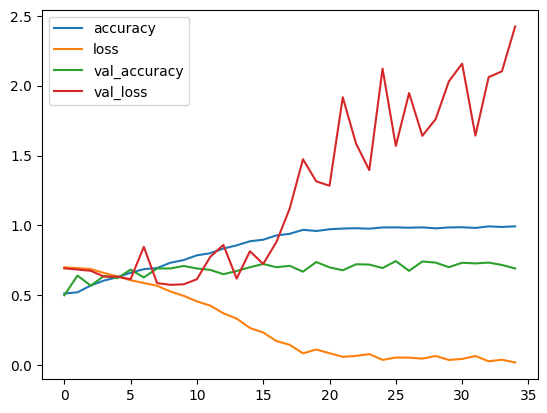

In [24]:
import matplotlib.pyplot as plt
import pandas as pd


pd.DataFrame(history.history).plot()